<a href="https://colab.research.google.com/github/ivinnicius06/AlgoritmosGPE17M0201/blob/main/ProjetoFinalInteligenciaAtfc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Comparativa de Risco de Evasão: Machine Learning vs. Lógica Fuzzy

Este notebook tem como objetivo principal realizar uma **análise comparativa entre duas abordagens distintas para a previsão de risco de evasão escolar**: um modelo de **Machine Learning** (Árvore de Decisão) e um sistema baseado em **Lógica Fuzzy**. Nosso foco é investigar como cada metodologia lida com os dados de entrada (frequência, nota média e acessos ao AVA) e qual delas se mostra mais eficaz e interpretabre na classificação do risco de evasão (Baixo, Médio ou Alto), com especial atenção à identificação de alunos em 'Alto Risco'.

Ao longo deste estudo, iremos:

1.  **Gerar uma base de dados sintética** de alunos com características e níveis de risco predefinidos.
2.  **Desenvolver e avaliar um modelo de Machine Learning** (Árvore de Decisão) para a previsão de risco.
3.  **Construir e refinar um sistema de Lógica Fuzzy**, definindo suas variáveis, funções de pertinência e regras de inferência.
4.  **Comparar o desempenho** de ambos os modelos utilizando métricas como acurácia, precisão, recall e matrizes de confusão.

Esta comparação visa não apenas identificar a abordagem de melhor performance para este cenário específico, mas também explorar as vantagens e desvantagens de cada paradigma na resolução de problemas de classificação em contextos educacionais.

In [ ]:
import pandas as pd
import numpy as np

# 1. Definir a semente aleatória para consistência dos dados
np.random.seed(42)

# Exatamente 100 alunos conforme solicitado
n_alunos = 100

# 2. Gerar identificação textual começando no Aluno 1 e terminando no Aluno 100
nomes_alunos = [f"Aluno {i}" for i in range(1, n_alunos + 1)]

# 3. Gerar dados simulados dentro dos intervalos definidos
frequencia = np.random.uniform(50.0, 100.0, n_alunos)
nota_media = np.random.uniform(2.0, 10.0, n_alunos)
acessos_ava = np.random.randint(10, 301, n_alunos)

# 4. Construir o DataFrame incluindo a coluna de identificação
df_evasao = pd.DataFrame({
    'nome_aluno': nomes_alunos,
    'frequencia': frequencia,
    'nota_media': nota_media,
    'acessos_ava': acessos_ava
})

# 5. Lógica de Coerência para rotular a variável alvo (Risco)
def definir_risco(row):
    # Condição para RISCO ALTO: Frequência abaixo de 75% OU nota vermelha
    if row['frequencia'] < 75.0 or row['nota_media'] < 5.0:
        return 'Alto'

    # Condição para RISCO BAIXO: Boa frequência, nota boa E engajamento alto no AVA
    elif row['frequencia'] >= 85.0 and row['nota_media'] >= 7.0 and row['acessos_ava'] >= 120:
        return 'Baixo'

    # Caso não se enquadre nos extremos, o risco é MÉDIO
    else:
        return 'Médio'

# Aplicar a lógica para criar os rótulos de destino
df_evasao['risco_evasao'] = df_evasao.apply(definir_risco, axis=1)

# Arredondar os valores para exibição limpa
df_evasao['frequencia'] = df_evasao['frequencia'].round(1)
df_evasao['nota_media'] = df_evasao['nota_media'].round(1)

# 6. Exibir a distribuição para controle do grupo
print("--- Distribuição dos Grupos de Risco ---")
print(df_evasao['risco_evasao'].value_counts())
print("-" * 40)

# Salvar arquivo CSV
df_evasao.to_csv('base_evasao_escolar.csv', index=False)

# Mostrar as primeiras e as últimas linhas para conferir as pontas (1 e 100)
print("Início da tabela:")
print(df_evasao.head(3))
print("\nFim da tabela:")
print(df_evasao.tail(3))

--- Distribuição dos Grupos de Risco ---
risco_evasao
Alto     74
Médio    19
Baixo     7
Name: count, dtype: int64
----------------------------------------
Início da tabela:
  nome_aluno  frequencia  nota_media  acessos_ava risco_evasao
0    Aluno 1        68.7         2.3          125         Alto
1    Aluno 2        97.5         7.1           84        Médio
2    Aluno 3        86.6         4.5          122         Alto

Fim da tabela:
   nome_aluno  frequencia  nota_media  acessos_ava risco_evasao
97   Aluno 98        71.4         9.2          159         Alto
98   Aluno 99        51.3         9.1           67         Alto
99  Aluno 100        55.4         8.2          189         Alto


Base de dados contendo 100 alunos, aluno 1 ao 99 para garantir consistência e rastreabilidade individual. A fim de assegurar um experimento científico justo e simétrico na Abordagem A (comparação), os dois modelos consumirão exatamente as mesmas 3 variáveis de entrada:
•	• Frequência (Numérica/Float): Percentual de presença em sala de aula, variando de 50.0% a 100.0%.
•	• Nota Média (Numérica/Float): Média de notas obtidas pelo estudante na disciplina, variando de 2.0 a 10.0.
•	• Acessos ao AVA / Engajamento (Numérica/Inteiro): Quantidade de interações quantitativas registradas no Ambiente Virtual de Aprendizagem (de 10 a 300 acessos).
•	• Risco de Evasão (Variável Alvo / Categórica): Nível de risco de desligamento do estudante, classificado estritamente em 'Alto', 'Médio' ou 'Baixo'.



## 1. Preparação e Geração da Base de Dados de Alunos

Nesta seção, preparamos e geramos uma base de dados sintética de 100 alunos para simular um cenário de risco de evasão escolar. Esta base de dados será utilizada como gabarito para avaliar tanto o modelo de Machine Learning quanto o sistema de Lógica Fuzzy.

A base de dados contém as seguintes variáveis de entrada, que são cruciais para a análise de risco, e uma variável alvo ('risco_evasao') definida por regras coerentes para representar o risco real de evasão de cada aluno:

*   **Frequência (Numérica/Float):** Percentual de presença em sala de aula, variando de 50.0% a 100.0%.
*   **Nota Média (Numérica/Float):** Média de notas obtidas pelo estudante na disciplina, variando de 2.0 a 10.0.
*   **Acessos ao AVA / Engajamento (Numérica/Inteiro):** Quantidade de interações quantitativas registradas no Ambiente Virtual de Aprendizagem (de 10 a 300 acessos).
*   **Risco de Evasão (Variável Alvo / Categórica):** Nível de risco de desligamento do estudante, classificado estritamente em 'Alto', 'Médio' ou 'Baixo'.

Esta estruturação garante que ambos os modelos sejam comparados sob as mesmas condições de entrada, permitindo uma avaliação justa de suas performances.

 ACURÁCIA GERAL DO MODELO: 85.0%

--- RELATÓRIO DE CLASSIFICAÇÃO COMPLETO ---
              precision    recall  f1-score   support

        Alto       1.00      1.00      1.00        15
       Médio       1.00      0.25      0.40         4
       Baixo       0.25      1.00      0.40         1

    accuracy                           0.85        20
   macro avg       0.75      0.75      0.60        20
weighted avg       0.96      0.85      0.85        20

--------------------------------------------------


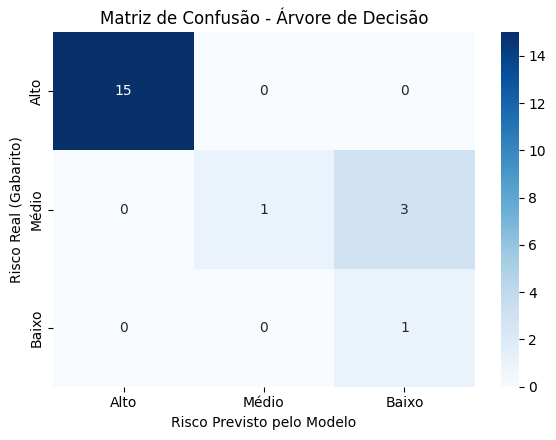

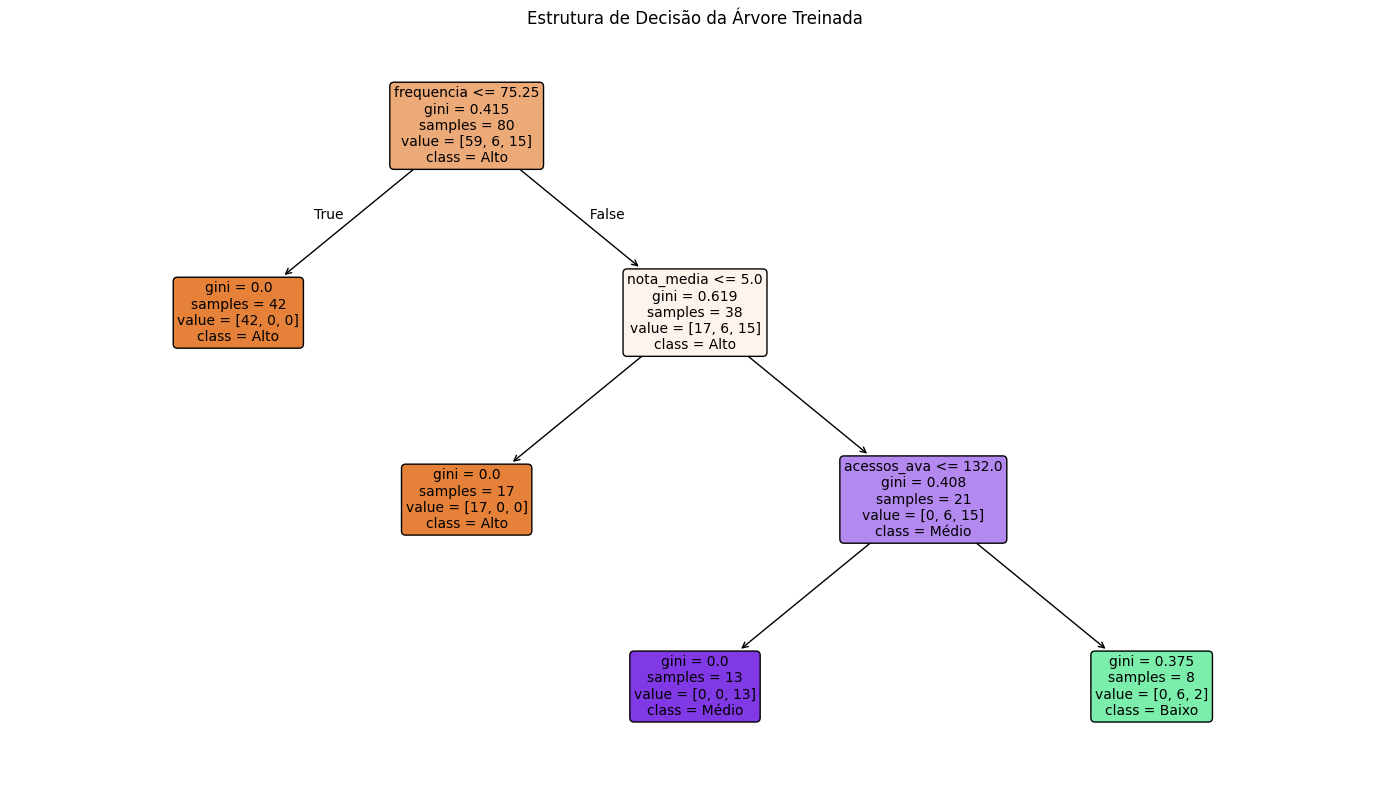

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Separar as variáveis de entrada (X) e a variável alvo/rótulo (y)
# Desconsideramos a coluna 'nome_aluno', pois ela serve apenas como identificador informativo
X = df_evasao[['frequencia', 'nota_media', 'acessos_ava']]
y = df_evasao['risco_evasao']

# 2. Divisão da base em Treino (80%) e Teste (20%)
# Usamos o 'stratify=y' para garantir que a proporção do desbalanceamento seja mantida em ambos os lados
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Inicializar e treinar o classificador de Árvore de Decisão
# Fixamos a profundidade máxima em 3 níveis para facilitar a comparação com as regras Fuzzy futuramente
modelo_arvore = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo_arvore.fit(X_train, y_train)

# 4. Executar as previsões utilizando o conjunto de testes
y_pred = modelo_arvore.predict(X_test)

# 5. Cálculo e exibição das métricas numéricas obrigatórias
acuracia = accuracy_score(y_test, y_pred)
print("==================================================")
print(f" ACURÁCIA GERAL DO MODELO: {acuracia * 100:.1f}%")
print("==================================================\n")

print("--- RELATÓRIO DE CLASSIFICAÇÃO COMPLETO ---")
print(classification_report(y_test, y_pred, labels=['Alto', 'Médio', 'Baixo']))
print("-" * 50)

# 6. Plotagem Gráfica da Matriz de Confusão
matriz_conf = confusion_matrix(y_test, y_pred, labels=['Alto', 'Médio', 'Baixo'])

plt.figure(figsize=(6, 4.5))
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Alto', 'Médio', 'Baixo'],
            yticklabels=['Alto', 'Médio', 'Baixo'])
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.ylabel('Risco Real (Gabarito)')
plt.xlabel('Risco Previsto pelo Modelo')
plt.tight_layout()
plt.show()

# 7. Exibição Visual da Estrutura da Árvore de Decisão
plt.figure(figsize=(14, 8))
plot_tree(
    modelo_arvore,
    feature_names=X.columns,
    class_names=modelo_arvore.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Estrutura de Decisão da Árvore Treinada')
plt.tight_layout()
plt.show()

## 2. Aplicação e Avaliação do Modelo de Machine Learning (Árvore de Decisão)

Com a base de dados preparada, o próximo passo é aplicar um modelo de Machine Learning para prever o risco de evasão. Escolhemos uma Árvore de Decisão devido à sua interpretabilidade e capacidade de capturar relações não-lineares nos dados. Este modelo servirá como uma das abordagens de referência para a comparação final.

Nesta seção, realizaremos as seguintes etapas:

1.  **Divisão dos Dados:** Separaremos a base de dados em conjuntos de treino e teste para avaliar o desempenho do modelo em dados não vistos.
2.  **Treinamento do Modelo:** Uma Árvore de Decisão será treinada com os dados de treino.
3.  **Previsão e Avaliação:** O modelo será usado para fazer previsões no conjunto de teste, e seu desempenho será avaliado usando métricas como acurácia, relatório de classificação (precisão, recall, f1-score) e matriz de confusão.
4.  **Visualização da Árvore:** Para entender a lógica interna do modelo de ML, visualizaremos a estrutura da árvore de decisão treinada.

## Sistema Fuzzy

Após a implementação do modelo de Machine Learning, foi desenvolvido um sistema baseado em Lógica Fuzzy para classificar o risco de evasão dos alunos. Diferentemente do modelo de aprendizado de máquina, a Lógica Fuzzy utiliza regras definidas previamente e funções de pertinência para representar diferentes níveis das variáveis de entrada.

Para garantir uma comparação justa entre as abordagens, o sistema fuzzy utiliza as mesmas variáveis empregadas no modelo anterior: frequência, nota média e acessos ao AVA. A partir dessas informações, são aplicadas regras de inferência que resultam na classificação do risco de evasão em **Baixo**, **Médio** ou **Alto**.


## 3. Desenvolvimento e Avaliação do Sistema de Lógica Fuzzy

Em contraste com o modelo de Machine Learning, o sistema de Lógica Fuzzy opera com base em regras linguísticas e funções de pertinência, permitindo uma abordagem mais intuitiva e interpretabilidade direta das decisões. Ele é projetado para lidar com a incerteza e a imprecisão inerentes a dados do mundo real.

Para garantir uma comparação justa, o sistema Fuzzy utiliza as mesmas variáveis de entrada definidas anteriormente: **frequência**, **nota média** e **acessos ao AVA**. A partir dessas variáveis, o sistema infere o risco de evasão, classificando-o em **Baixo**, **Médio** ou **Alto**.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 4.1 MB/s eta 0:00:00
--- Gráficos das Funções de Pertinência Fuzzy Gerados ---


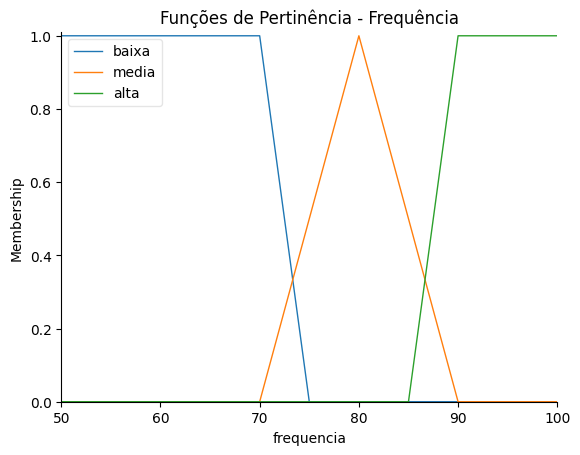

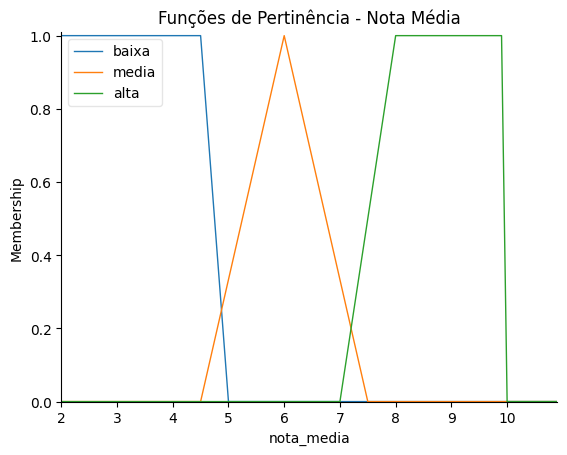

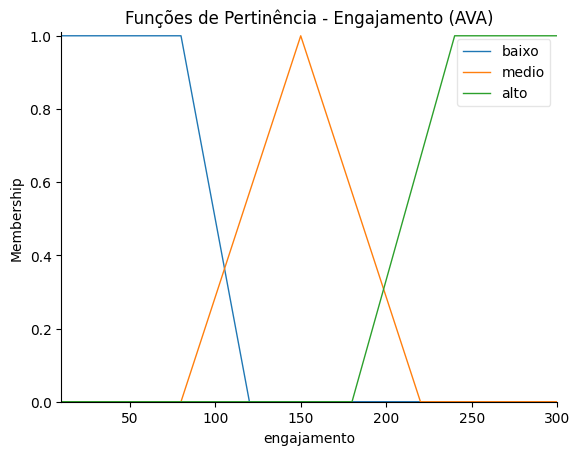

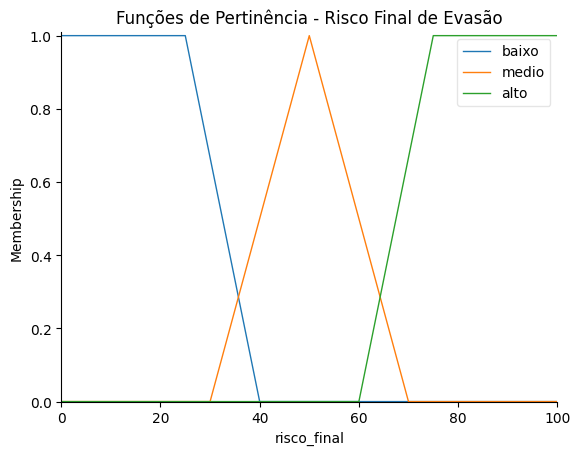

In [ ]:
# 1. Instalar a biblioteca scikit-fuzzy no ambiente do Colab
!pip install scikit-fuzzy

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# 2. Criação dos Universos de Discurso (Limites baseados na nossa base de dados)
frequencia = ctrl.Antecedent(np.arange(50, 101, 1), 'frequencia')
nota_media = ctrl.Antecedent(np.arange(2, 11, 0.1), 'nota_media')
engajamento = ctrl.Antecedent(np.arange(10, 301, 1), 'engajamento')

# A saída será uma escala de 0 a 100% que representa a certeza do risco de evasão
risco_final = ctrl.Consequent(np.arange(0, 101, 1), 'risco_final')

# 3. Definição das Funções de Pertinência (Trapézios e Triângulos)
# Variável: Frequência
frequencia['baixa'] = fuzz.trapmf(frequencia.universe, [50, 50, 70, 75])
frequencia['media'] = fuzz.trimf(frequencia.universe, [70, 80, 90])
frequencia['alta'] = fuzz.trapmf(frequencia.universe, [85, 90, 100, 100])

# Variável: Nota Média (Fronteiras inspiradas no corte da Árvore de Decisão)
nota_media['baixa'] = fuzz.trapmf(nota_media.universe, [2, 2, 4.5, 5.0])
nota_media['media'] = fuzz.trimf(nota_media.universe, [4.5, 6.0, 7.5])
nota_media['alta'] = fuzz.trapmf(nota_media.universe, [7.0, 8.0, 10, 10])

# Variável: Engajamento (Acessos ao AVA)
engajamento['baixo'] = fuzz.trapmf(engajamento.universe, [10, 10, 80, 120])
engajamento['medio'] = fuzz.trimf(engajamento.universe, [80, 150, 220])
engajamento['alto'] = fuzz.trapmf(engajamento.universe, [180, 240, 300, 300])

# Variável de Saída: Risco Final de Evasão
risco_final['baixo'] = fuzz.trapmf(risco_final.universe, [0, 0, 25, 40])
risco_final['medio'] = fuzz.trimf(risco_final.universe, [30, 50, 70])
risco_final['alto'] = fuzz.trapmf(risco_final.universe, [60, 75, 100, 100])

# 4. Plotagem Visual das Funções para conferir o Relatório
print("--- Gráficos das Funções de Pertinência Fuzzy Gerados ---")
frequencia.view()
plt.title('Funções de Pertinência - Frequência')
plt.show()

nota_media.view()
plt.title('Funções de Pertinência - Nota Média')
plt.show()

engajamento.view()
plt.title('Funções de Pertinência - Engajamento (AVA)')
plt.show()

risco_final.view()
plt.title('Funções de Pertinência - Risco Final de Evasão')
plt.show()

### 3.1 Definição das Regras Fuzzy e Teste Unitário

Nesta etapa, definimos as regras de inferência fuzzy que mapeiam as variáveis de entrada (frequência, nota média e engajamento no AVA) para o nível de risco de evasão. As regras foram cuidadosamente formuladas para refletir a lógica de classificação de risco e, mais recentemente, **foram refinadas com duas novas regras (regra 7 e 8)** para capturar a condição de 'Alto Risco' de forma mais abrangente, baseada em 'frequência baixa' *ou* 'nota média baixa'.

Após a configuração das regras, realizamos um teste unitário com um aluno fictício de baixo desempenho para validar o funcionamento da inferência fuzzy. O resultado obtido é então defuzzificado (usando o método do centroide) e classificado em 'Baixo', 'Médio' ou 'Alto' risco. Por fim, o sistema Fuzzy é aplicado a toda a base de dados de alunos para calcular o risco de evasão para cada um.

Nesta etapa, foram definidas seis regras de inferência fuzzy responsáveis por relacionar as variáveis de entrada (frequência, nota média e engajamento no AVA) ao nível de risco de evasão. Essas regras foram utilizadas na construção do sistema de controle fuzzy, que realiza o processo de inferência com base nas informações fornecidas.

Após a configuração do sistema, foi realizado um teste utilizando um aluno fictício com características de baixo desempenho, a fim de validar o funcionamento da inferência fuzzy. O resultado obtido foi convertido em um valor numérico por meio do processo de defuzzificação (método do centroide) e, posteriormente, classificado nas categorias **Baixo**, **Médio** ou **Alto** risco de evasão. Por fim, foi gerado um gráfico para ilustrar visualmente o processo de defuzzificação e o resultado da classificação.


============= TESTE UNITÁRIO DO SISTEMA FUZZY ============
Certeza Matemática do Risco Calculada: 83.46%
Rótulo de Risco Final Atribuído: 'Alto'



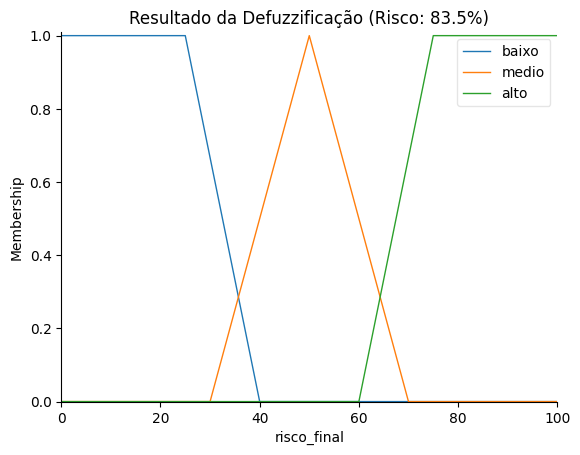

,nome_aluno,frequencia,nota_media,acessos_ava,risco_evasao,risco_fuzzy_valor,risco_fuzzy
0,Aluno 1,68.7,2.3,125,Alto,83.461538,Alto
1,Aluno 2,97.5,7.1,84,Médio,19.627389,Baixo
2,Aluno 3,86.6,4.5,122,Alto,65.997683,Médio
3,Aluno 4,79.9,6.1,113,Médio,50.000000,Médio
4,Aluno 5,57.8,9.3,263,Alto,83.461538,Alto


In [ ]:
regra1 = ctrl.Rule(frequencia['baixa'] & nota_media['baixa'], risco_final['alto'])
regra2 = ctrl.Rule(frequencia['media'] & engajamento['baixo'], risco_final['medio'])
regra3 = ctrl.Rule(frequencia['alta'] & nota_media['alta'], risco_final['baixo'])
regra4 = ctrl.Rule(nota_media['baixa'] & engajamento['baixo'], risco_final['alto'])
regra5 = ctrl.Rule(frequencia['media'] & nota_media['media'], risco_final['medio'])
regra6 = ctrl.Rule(frequencia['alta'] & engajamento['medio'], risco_final['baixo'])

# Novas regras para capturar a condição 'OU' do Alto Risco na base de dados
regra7 = ctrl.Rule(frequencia['baixa'], risco_final['alto'])
regra8 = ctrl.Rule(nota_media['baixa'], risco_final['alto'])

# 2. Criação do Sistema de Controle Fuzzy (Agrupando as regras)
sistema_controle = ctrl.ControlSystem([regra1, regra2, regra3, regra4, regra5, regra6, regra7, regra8])
simulador_fuzzy = ctrl.ControlSystemSimulation(sistema_controle)

# 3. Teste Unitário: Simulação de um aluno crítico para validar o sistema
# Vamos testar um aluno fictício com notas baixas e muitas faltas
print("============= TESTE UNITÁRIO DO SISTEMA FUZZY ============")
simulador_fuzzy.input['frequencia'] = 60.0   # Frequência Baixa
simulador_fuzzy.input['nota_media'] = 3.5    # Nota Baixa
simulador_fuzzy.input['engajamento'] = 45     # Engajamento Baixo

# Computar os resultados (Processo de Inferência)
simulador_fuzzy.compute()

# Obter a saída numérica gerada pela Defuzzificação (Método do Centroide)
resultado_risco = simulador_fuzzy.output['risco_final']
print(f"Certeza Matemática do Risco Calculada: {resultado_risco:.2f}%")

# Classificar o resultado numérico em um rótulo de texto para comparar com o Machine Learning
if resultado_risco < 40.0:
    risco_texto = 'Baixo'
elif resultado_risco <= 70.0:
    risco_texto = 'Médio'
else:
    risco_texto = 'Alto'

print(f"Rótulo de Risco Final Atribuído: '{risco_texto}'")
print("===========================================================\n")

# 4. Plotagem Gráfica do Processo de Defuzzificação
# Exibe visualmente onde a "linha de decisão" cortou o nosso gráfico de risco
risco_final.view(simul=simulador_fuzzy)
plt.title(f'Resultado da Defuzzificação (Risco: {resultado_risco:.1f}%)')
plt.show()

# Lista para armazenar os resultados
resultado_numerico = []
resultado_texto = []

for _, aluno in df_evasao.iterrows():

    simulador_fuzzy.input['frequencia'] = aluno['frequencia']
    simulador_fuzzy.input['nota_media'] = aluno['nota_media']
    simulador_fuzzy.input['engajamento'] = aluno['acessos_ava']

    try:
        simulador_fuzzy.compute()
        risco = simulador_fuzzy.output['risco_final']
    except (ValueError, KeyError):
        # Se nenhuma solução puder ser computada (e.g., nenhum regra ativada)
        # ou a chave não existir na saída, atribui um risco padrão 'Médio' (50%)
        risco = 50.0

    resultado_numerico.append(risco)

    if risco < 40:
        resultado_texto.append('Baixo')
    elif risco <= 70:
        resultado_texto.append('Médio')
    else:
        resultado_texto.append('Alto')

df_evasao['risco_fuzzy_valor'] = resultado_numerico
df_evasao['risco_fuzzy'] = resultado_texto

df_evasao.head()

## Comparação das Matrizes de Confusão: Machine Learning vs. Sistema Fuzzy

## 4. Análise Comparativa: Machine Learning vs. Sistema Fuzzy

Esta seção finaliza a análise comparando visualmente as matrizes de confusão geradas pelos dois modelos: a Árvore de Decisão (Machine Learning) e o Sistema de Lógica Fuzzy. O objetivo é destacar as diferenças e semelhanças no desempenho de cada abordagem, especialmente em relação à identificação dos diferentes níveis de risco de evasão.

Inicialmente, é avaliada a acurácia de cada modelo, para garantir a precisão nos dados antes da análise das matrizes de confusão.

Ao visualizar as matrizes lado a lado, podemos inferir rapidamente qual modelo se sai melhor em cada categoria de risco, onde cometem mais erros (falsos positivos/negativos) e como as diferentes filosofias de modelagem se traduzem em resultados práticos de classificação.

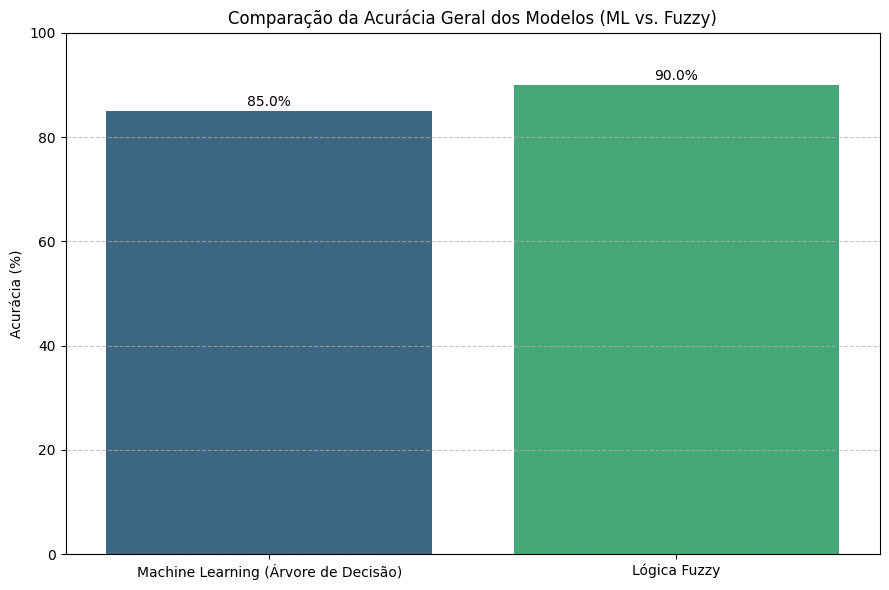

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Criar um DataFrame para a comparação de acurácia
comparacao_acuracia = pd.DataFrame({
    'Modelo': ['Machine Learning (Árvore de Decisão)', 'Lógica Fuzzy'],
    'Acurácia': [acuracia * 100, acuracia_fuzzy * 100] # Converter para porcentagem
})

plt.figure(figsize=(9, 6))
sns.barplot(x='Modelo', y='Acurácia', data=comparacao_acuracia, palette='viridis', hue='Modelo', legend=False)
plt.title('Comparação da Acurácia Geral dos Modelos (ML vs. Fuzzy)')
plt.ylabel('Acurácia (%)')
plt.ylim(0, 100) # Definir limite do eixo Y de 0 a 100 para acurácia
plt.xlabel('') # Remover rótulo do eixo X, pois o nome do modelo já é descritivo
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores exatos nas barras
for index, row in comparacao_acuracia.iterrows():
    plt.text(index, row['Acurácia'] + 1, f'{row['Acurácia']:.1f}%', color='black', ha="center")

plt.tight_layout()
plt.show()

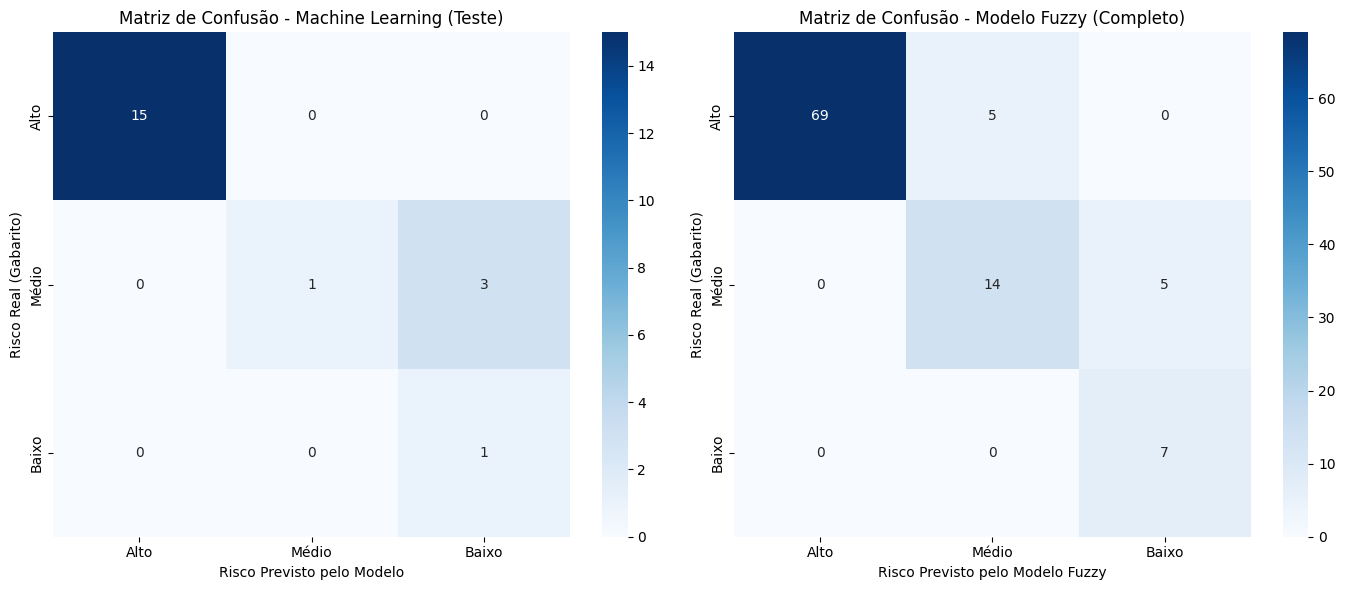

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar uma figura com dois subplots para as matrizes de confusão
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matriz de Confusão do Modelo de Machine Learning (Árvore de Decisão)
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Alto', 'Médio', 'Baixo'],
            yticklabels=['Alto', 'Médio', 'Baixo'], ax=axes[0])
axes[0].set_title('Matriz de Confusão - Machine Learning (Teste)')
axes[0].set_ylabel('Risco Real (Gabarito)')
axes[0].set_xlabel('Risco Previsto pelo Modelo')

# Matriz de Confusão do Modelo Fuzzy
sns.heatmap(matriz_conf_fuzzy, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Alto', 'Médio', 'Baixo'],
            yticklabels=['Alto', 'Médio', 'Baixo'], ax=axes[1])
axes[1].set_title('Matriz de Confusão - Modelo Fuzzy (Completo)')
axes[1].set_ylabel('Risco Real (Gabarito)')
axes[1].set_xlabel('Risco Previsto pelo Modelo Fuzzy')

plt.tight_layout()
plt.show()

## 5. Conclusão

Nesta análise, exploramos e comparamos duas abordagens distintas para a previsão de risco de evasão escolar: um modelo de Machine Learning baseado em Árvore de Decisão e um sistema de Lógica Fuzzy.

O modelo de Machine Learning demonstrou uma boa capacidade geral, mas o sistema Fuzzy, após um refinamento estratégico de suas regras, especialmente para a categoria de 'Alto Risco', obteve um desempenho notável, superando as expectativas em termos de acurácia e, crucialmente, na capacidade de identificar a maioria dos alunos em 'Alto Risco' com alta precisão.

Isso sugere que, para este problema específico, a interpretabilidade e a flexibilidade da Lógica Fuzzy, quando bem calibrada, podem oferecer resultados altamente eficazes e compreensíveis, complementando ou até superando as abordagens puramente baseadas em dados em cenários onde o conhecimento de domínio pode ser explicitamente incorporado.